In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch

project_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
sys.path.append(project_dir)

from tools import JSON_Read, importance_analyse_lmdKAN#, plotly_multi_scatter
from tools import KAN_es_2 as KAN_es
from tools import lmdKAN_es
SCRIPT_DIR = os.path.abspath('')


def load_map(n_file, spec_file):
    """Loads 2D fluorescence map and returns as df.
    """
    df = pd.read_csv(spec_file + f'/{n_file}' + '.csv', index_col=0).iloc[1:, :-1].T

    # function for renaming labels and indexes in map
    vec_renaming = lambda vec_list: [float(name.split()[0]) for name in vec_list]

    df.columns = vec_renaming(df.columns)
    df.index = vec_renaming(df.index)

    return df

def get_wavelength(spec_file, n_file=1):
    """Loads array of wavelength.
    """
    df = pd.read_csv(spec_file + f'/{n_file}' + '.csv', index_col=0).iloc[1:, :-1].T

    # function for renaming labels and indexes in map
    vec_renaming = lambda vec_list: [float(name.split()[0]) for name in vec_list]

    l_wavelenth = np.array(vec_renaming(df.columns))

    return l_wavelenth

def get_y(l_ions, spec_file):
    """Forms and returns data of ions concentration - y data.
    """
    df = pd.read_excel(spec_file + f'/example_Y_answers.xlsx', index_col=0)

    y = df[l_ions].to_numpy(dtype=np.float64).ravel()

    return y

def get_x(wave_length, spec_file):
    """Forms and returns data of fluorescence - x data.
    """
    l_indexes = pd.read_excel(spec_file + f'/example_Y_answers.xlsx', index_col=0).index
    l_X = []
    for n_file in l_indexes:
        fl_map = load_map(n_file, spec_file)
        l_X.append(fl_map.loc[wave_length])
    X = pd.DataFrame(l_X, index = l_indexes, dtype=np.float64)

    return X


def get_sqz_input(x_axis, y_axis):
    ''' Evaluate squeezed data from curve.
    '''
    i_max = np.argmax(y_axis)
    I = y_axis[i_max]  # Max I
    c_I = x_axis[i_max]  # Coordinate of max I

    diff_I = np.absolute(y_axis-I/2)
    c_I2_left = x_axis[ np.argmin(diff_I[:i_max]) ]  # Left I/2 coordinate
    c_I2_right = x_axis[ np.argmin(diff_I[i_max:])+i_max]  # Right I/2 coordinate

    c_I2 = np.mean([c_I2_left, c_I2_right])  # Mean center coordinate on I/2 
    disp_I2 = np.abs(c_I2_right-c_I2_left)  # Width of curve on I/2 y-level

    integr_ratio = np.sum(y_axis[i_max+1:]) / np.sum(y_axis[:i_max])

    sqz_input = [I, c_I, c_I2, disp_I2, integr_ratio]
    
    
    return sqz_input

def get_all_sqz_input(matr_x, matr_y):
    matr_sqz_input = []
    for x_axis, y_axis in zip(matr_x, matr_y):
        matr_sqz_input.append(get_sqz_input(x_axis, y_axis))


    return np.array(matr_sqz_input)

    matr_sqz_input = []
    for x_axis, y_axis in zip(matr_x, matr_y):
        matr_sqz_input.append(get_sqz_input(x_axis, y_axis))


    return np.array(matr_sqz_input)

def scatter_prediction_skl(model, 
                           x, 
                           y_true, 
                           title = ""):
    """Evaluates MSE and R^2 of model. 
    Draws scatter plot of (y_true, y_predicted).
    Returns  (mse, r2)
    """
    y_pred = model.predict(x)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(5,5))
    plt.plot(y_true, y_pred, 'o', markersize=4, alpha = 0.8) 
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], linewidth=1.5, alpha = 1.0, color='r') 
    ax.text(1, 3.5, 
            f"$MSE$={round(float(mse), 3)} \n$RMSE$={round(float(mse)**0.5, 3)} \n$R^2$={round(float(r2), 3)}",
            fontsize=14)
    ax.set_title('')
    ax.set_xlabel("True conc.", size=14)
    ax.set_ylabel("Predicted conc.", size=14)
    # Increase tick label sizes for x-axis
    for label in ax.get_xticklabels():
      label.set_fontsize(14)
    for label in ax.get_yticklabels():
      label.set_fontsize(14)
    
    plt.show()

    
    return mse, r2


EXCITE_WAVE_LENGTH = 350
SPEC_FOLDER = 'data_example'
PREDICT_IONS = 'Cr'

TRAIN_TEST_RATIO = 0.9
VALIDATION_TRAIN_RATIO = 0.222

c:\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Determination of KAN, $\lambda$-KAN classes

In [2]:
from sklearn.base import RegressorMixin, BaseEstimator, _fit_context
from sklearn.utils.validation import check_is_fitted


class KANRegressor(RegressorMixin, BaseEstimator):
    """Sci-kit learn wrapper for pykan model.
    
    Hierarchical inheritance chain of classes:
    1. pykan.kan --> 
    2. --> KAN_es: pykan.kan with early stopping, made as in skl.neural_network.MLPRegressor -->
    3. --> KANRegressor: pykan.kan wrapped in (RegressorMixin, BaseEstimator) for compatibility with skl interface.
           Uses params, inspired by skl.neural_network.MLPRegressor params logic.
    """

    # This is a dictionary allowing to define the type of parameters.
    # It used to validate parameter within the `_fit_context` decorator.
    
    _parameter_constraints = {}
    
    _d_solver_translation = {
        'lbfgs': 'LBFGS',
        'adam': 'Adam'
    }

    def __init__(self, 
                 # kan.__init__ args
                 hidden_layer_sizes=None,
                 grid=3,
                 k=3,
                 seed=1,
                 device='cpu',
                 # kan.train_es args
                 tol=1e-3,
                 n_iter_no_change=10,
                 solver='lbfgs',
                 max_iter=100,
                 learning_rate_init=1.0,
                 validation_fraction=0.1,
                 # additional kan.__init__ args
                 mult_arity = 2, noise_scale=0.3, scale_base_mu=0.0, scale_base_sigma=1.0, base_fun='silu', symbolic_enabled=True, affine_trainable=False, grid_eps=0.02, grid_range=[-1, 1], sp_trainable=True, sb_trainable=True, save_act=True, sparse_init=False, auto_save=True, first_init=True, ckpt_path='./model', state_id=0, round=0,
                 # additional kan.train_es args
                 log=1, lamb=0., lamb_l1=1., lamb_entropy=2., lamb_coef=0., lamb_coefdiff=0., update_grid=True, grid_update_num=10, loss_fn=None, start_grid_update_step=-1, stop_grid_update_step=50, batch=-1, metrics=None, singularity_avoiding=False, save_fig=False, in_vars=None, out_vars=None, beta=3, save_fig_freq=1, img_folder='./video',  y_th=1000., reg_metric='edge_forward_spline_n', display_metrics=None
                 ):
        '''
        Init method. Saving all kan.__init__ and kan.fit args.
        
        Args:
        -----
            -- kan.__init__ parameteres --
            hidden_layer_sizes : list
                the ith element represents the number of neurons in the ith hidden layer.
            grid : int
                number of grid intervals. Default: 3.
            k : int
                order of piecewise polynomial. Default: 3.
            mult_arity : int, or list of int lists
                multiplication arity for each multiplication node (the number of numbers to be multiplied)
            noise_scale : float
                initial injected noise to spline.
            base_fun : str
                the residual function b(x). Default: 'silu'
            symbolic_enabled : bool
                compute (True) or skip (False) symbolic computations (for efficiency). By default: True. 
            affine_trainable : bool
                affine parameters are updated or not. Affine parameters include node_scale, node_bias, subnode_scale, subnode_bias
            grid_eps : float
                When grid_eps = 1, the grid is uniform; when grid_eps = 0, the grid is partitioned using percentiles of samples. 0 < grid_eps < 1 interpolates between the two extremes.
            grid_range : list/np.array of shape (2,))
                setting the range of grids. Default: [-1,1]. This argument is not important if fit(update_grid=True) (by default updata_grid=True)
            sp_trainable : bool
                If true, scale_sp is trainable. Default: True.
            sb_trainable : bool
                If true, scale_base is trainable. Default: True.
            device : str
                device
            seed : int
                random seed
            save_act : bool
                indicate whether intermediate activations are saved in forward pass
            sparse_init : bool
                sparse initialization (True) or normal dense initialization. Default: False.
            auto_save : bool
                indicate whether to automatically save a checkpoint once the model is modified
            state_id : int
                the state of the model (used to save checkpoint)
            ckpt_path : str
                the folder to store checkpoints. Default: './model'
            round : int
                the number of times rewind() has been called
            
            -- kan.train_es parameteres --
            tol : float
                Delta of validation fit which doesn`t count as fitness improvement. (Tolerence of training).
            n_iter_no_change : int
                Number of iteration with no fit change to early stopping.
            solver : str
                "lbfgs" or "adam"
            max_iter : int
                training steps
            learning_rate_init: float
                learning rate
            log : int
                logging frequency
            lamb : float
                overall penalty strength
            lamb_l1 : float
                l1 penalty strength
            lamb_entropy : float
                entropy penalty strength
            lamb_coef : float
                coefficient magnitude penalty strength
            lamb_coefdiff : float
                difference of nearby coefficits (smoothness) penalty strength
            update_grid : bool
                If True, update grid regularly before stop_grid_update_step
            grid_update_num : int
                the number of grid updates before stop_grid_update_step
            stop_grid_update_step : int
                no grid updates after this training step
            batch : int
                batch size, if -1 then full.
            small_mag_threshold : float
                threshold to determine large or small numbers (may want to apply larger penalty to smaller numbers)
            small_reg_factor : float
                penalty strength applied to small factors relative to large factos
            save_fig_freq : int
                save figure every (save_fig_freq) step
        '''
        
        self.hidden_layer_sizes, self.grid, self.k, self.seed, self.device = hidden_layer_sizes, grid, k, seed, device
        self.mult_arity, self.noise_scale, self.scale_base_mu, self.scale_base_sigma, self.base_fun, self.symbolic_enabled, self.affine_trainable, self.grid_eps, self.grid_range, self.sp_trainable, self.sb_trainable, self.save_act, self.sparse_init, self.auto_save, self.first_init, self.ckpt_path, self.state_id, self.round = mult_arity, noise_scale, scale_base_mu, scale_base_sigma, base_fun, symbolic_enabled, affine_trainable, grid_eps, grid_range, sp_trainable, sb_trainable, save_act, sparse_init, auto_save, first_init, ckpt_path, state_id, round
        
        self.tol, self.n_iter_no_change, self.solver, self.max_iter, self.learning_rate_init, self.validation_fraction = tol, n_iter_no_change, solver, max_iter, learning_rate_init, validation_fraction
        self.log, self.lamb, self.lamb_l1, self.lamb_entropy, self.lamb_coef, self.lamb_coefdiff, self.update_grid, self.grid_update_num, self.loss_fn, self.start_grid_update_step, self.stop_grid_update_step, self.batch, self.metrics, self.singularity_avoiding, self.save_fig, self.in_vars, self.out_vars, self.beta, self.save_fig_freq, self.img_folder, self.y_th, self.reg_metric, self.display_metrics = log, lamb, lamb_l1, lamb_entropy, lamb_coef, lamb_coefdiff, update_grid, grid_update_num, loss_fn, start_grid_update_step, stop_grid_update_step, batch, metrics, singularity_avoiding, save_fig, in_vars, out_vars, beta, save_fig_freq, img_folder, y_th, reg_metric, display_metrics
        
    @_fit_context(prefer_skip_nested_validation=True)
    def fit(self, X, y, speed=False):
        """A reference implementation of a fitting function.

        Parameters
        ----------
        X : {array-like, sparse matrix}, shape (n_samples, n_features)
            The training input samples.

        y : array-like, shape (n_samples,) or (n_samples, n_outputs)
            The target values (class labels in classification, real numbers in
            regression).

        Returns
        -------
        self : object
            Returns self.
        """
        # `_validate_data` is defined in the `BaseEstimator` class.
        # It allows to:
        # - run different checks on the input data;
        # - define some attributes associated to the input data: `n_features_in_` and
        #   `feature_names_in_`.
        
        # Make sure self.hidden_layer_sizes is a list
        hidden_layer_sizes = self.hidden_layer_sizes
        if not hasattr(hidden_layer_sizes, "__iter__"):
            hidden_layer_sizes = [hidden_layer_sizes]
        hidden_layer_sizes = list(hidden_layer_sizes)
        
        #X, y = self._validate_data(X, y, accept_sparse=True)
        n_features = X.shape[1]
        
        # Ensure y is 2D
        if y.ndim == 1:
            y = y.reshape((-1, 1))
            
        if not hasattr(self, "is_fitted_"): self.is_fitted_ = False
        
        if not self.is_fitted_:
            self.n_outputs_ = y.shape[1]
        
            self.width = [n_features] + self.hidden_layer_sizes + [self.n_outputs_]
            self.kan = KAN_es(width=self.width, grid=self.grid, k=self.k, seed=self.seed, device=self.device,
                              mult_arity=self.mult_arity, noise_scale=self.noise_scale, scale_base_mu=self.scale_base_mu, scale_base_sigma=self.scale_base_sigma, base_fun=self.base_fun, symbolic_enabled=self.symbolic_enabled, affine_trainable=self.affine_trainable, grid_eps=self.grid_eps, grid_range=self.grid_range, sp_trainable=self.sp_trainable, sb_trainable=self.sb_trainable, save_act=self.save_act, sparse_init=self.sparse_init, auto_save=self.auto_save, first_init=self.first_init, ckpt_path=self.ckpt_path, state_id=self.state_id, round=self.round)
        
        if speed: self.kan.speed()
        
        X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                        test_size=self.validation_fraction,
                                                        random_state=self.seed)
                    
        kan_dataset = {'train_input': torch.tensor(np.array(X_train), dtype=torch.float),
                       'train_label': torch.tensor(np.array(y_train), dtype=torch.float),
                       'test_input': torch.tensor(np.array(X_val), dtype=torch.float),
                       'test_label': torch.tensor(np.array(y_val), dtype=torch.float)}
        
        results = self.kan.fit(kan_dataset, 
                               tol=self.tol, 
                               n_iter_no_change=self.n_iter_no_change,
                               opt=self._d_solver_translation[self.solver], 
                               lr = self.learning_rate_init,
                               steps=self.max_iter,
                               log=self.log, lamb=self.lamb, lamb_l1=self.lamb_l1, lamb_entropy=self.lamb_entropy, lamb_coef=self.lamb_coef, lamb_coefdiff=self.lamb_coefdiff, update_grid=self.update_grid, grid_update_num=self.grid_update_num, loss_fn=self.loss_fn, stop_grid_update_step=self.stop_grid_update_step, batch=self.batch, singularity_avoiding=self.singularity_avoiding, save_fig=self.save_fig, in_vars=self.in_vars, out_vars=self.out_vars, beta=self.beta, save_fig_freq=self.save_fig_freq, img_folder=self.img_folder, y_th=self.y_th, reg_metric=self.reg_metric, display_metrics=self.display_metrics
                                )
        
        self. kan.results = results
        self.is_fitted_ = True
        # `fit` should always return `self`
        return self

    def predict(self, X):
        """A reference implementation of a predicting function.

        Parameters
        ----------
        X : {array-like, sparse matrix}, shape (n_samples, n_features)
            The training input samples.

        Returns
        -------
        y : ndarray of shape (n_samples, n_outputs)
            The predicted values.
        """
        # Check if fit had been called
        check_is_fitted(self)
        # We need to set reset=False because we don't want to overwrite `n_features_in_`
        # `feature_names_in_` but only check that the shape is consistent.
        #X = self._validate_data(X, accept_sparse=True, reset=False)
        
        x = torch.tensor(np.array(X), dtype=torch.float)
        pred = self.kan.forward(x).detach().numpy()
        
        return pred
    

class lmdKANRegressor(RegressorMixin, BaseEstimator):
    """Sci-kit learn wrapper for pykan model.
    
    Hierarchical inheritance chain of classes:
    1. pykan.kan --> 
    2. --> lmdKAN_es: pykan.kan with early stopping, made as in skl.neural_network.MLPRegressor -->
    3. --> KANRegressor: pykan.kan wrapped in (RegressorMixin, BaseEstimator) for compatibility with skl interface.
           Uses params, inspired by skl.neural_network.MLPRegressor params logic.
    """

    # This is a dictionary allowing to define the type of parameters.
    # It used to validate parameter within the `_fit_context` decorator.
    
    _parameter_constraints = {}
    
    _d_solver_translation = {
        'lbfgs': 'LBFGS',
        'adam': 'Adam'
    }

    def __init__(self, 
                 # kan.__init__ args
                 hidden_layer_sizes=None,
                 grid=3,
                 k=3,
                 seed=1,
                 device='cpu',
                 # kan.train_es args
                 tol=1e-3,
                 n_iter_no_change=10,
                 solver='lbfgs',
                 max_iter=100,
                 learning_rate_init=1.0,
                 validation_fraction=0.1,
                 # additional kan.__init__ args
                 mult_arity = 2, noise_scale=0.3, scale_base_mu=0.0, scale_base_sigma=1.0, base_fun='silu', symbolic_enabled=True, affine_trainable=False, grid_eps=0.02, grid_range=[-1, 1], sp_trainable=True, sb_trainable=True, save_act=True, sparse_init=False, auto_save=True, first_init=True, ckpt_path='./model', state_id=0, round=0,
                 lmd_init_vector=None, lmd_init_mu=0.0, lmd_init_sigma=1.0, lmd_trainable=True,
                 # additional kan.train_es args
                 log=1, lamb=0., lamb_l1=1., lamb_entropy=2., lamb_coef=0., lamb_coefdiff=0., update_grid=True, grid_update_num=10, loss_fn=None, start_grid_update_step=-1, stop_grid_update_step=50, batch=-1, metrics=None, singularity_avoiding=False, save_fig=False, in_vars=None, out_vars=None, beta=3, save_fig_freq=1, img_folder='./video',  y_th=1000., reg_metric='edge_forward_spline_n', display_metrics=None
                 ):
        '''
        Init method. Saving all kan.__init__ and kan.fit args.
        
        Args:
        -----
            -- kan.__init__ parameteres --
            hidden_layer_sizes : list
                the ith element represents the number of neurons in the ith hidden layer.
            grid : int
                number of grid intervals. Default: 3.
            k : int
                order of piecewise polynomial. Default: 3.
            mult_arity : int, or list of int lists
                multiplication arity for each multiplication node (the number of numbers to be multiplied)
            noise_scale : float
                initial injected noise to spline.
            base_fun : str
                the residual function b(x). Default: 'silu'
            symbolic_enabled : bool
                compute (True) or skip (False) symbolic computations (for efficiency). By default: True. 
            affine_trainable : bool
                affine parameters are updated or not. Affine parameters include node_scale, node_bias, subnode_scale, subnode_bias
            grid_eps : float
                When grid_eps = 1, the grid is uniform; when grid_eps = 0, the grid is partitioned using percentiles of samples. 0 < grid_eps < 1 interpolates between the two extremes.
            grid_range : list/np.array of shape (2,))
                setting the range of grids. Default: [-1,1]. This argument is not important if fit(update_grid=True) (by default updata_grid=True)
            sp_trainable : bool
                If true, scale_sp is trainable. Default: True.
            sb_trainable : bool
                If true, scale_base is trainable. Default: True.
            device : str
                device
            seed : int
                random seed
            save_act : bool
                indicate whether intermediate activations are saved in forward pass
            sparse_init : bool
                sparse initialization (True) or normal dense initialization. Default: False.
            auto_save : bool
                indicate whether to automatically save a checkpoint once the model is modified
            state_id : int
                the state of the model (used to save checkpoint)
            ckpt_path : str
                the folder to store checkpoints. Default: './model'
            round : int
                the number of times rewind() has been called
            
            -- kan.train_es parameteres --
            tol : float
                Delta of validation fit which doesn`t count as fitness improvement. (Tolerence of training).
            n_iter_no_change : int
                Number of iteration with no fit change to early stopping.
            solver : str
                "lbfgs" or "adam"
            max_iter : int
                training steps
            learning_rate_init: float
                learning rate
            log : int
                logging frequency
            lamb : float
                overall penalty strength
            lamb_l1 : float
                l1 penalty strength
            lamb_entropy : float
                entropy penalty strength
            lamb_coef : float
                coefficient magnitude penalty strength
            lamb_coefdiff : float
                difference of nearby coefficits (smoothness) penalty strength
            update_grid : bool
                If True, update grid regularly before stop_grid_update_step
            grid_update_num : int
                the number of grid updates before stop_grid_update_step
            stop_grid_update_step : int
                no grid updates after this training step
            batch : int
                batch size, if -1 then full.
            small_mag_threshold : float
                threshold to determine large or small numbers (may want to apply larger penalty to smaller numbers)
            small_reg_factor : float
                penalty strength applied to small factors relative to large factos
            save_fig_freq : int
                save figure every (save_fig_freq) step
        '''
        
        self.hidden_layer_sizes, self.grid, self.k, self.seed, self.device = hidden_layer_sizes, grid, k, seed, device
        self.mult_arity, self.noise_scale, self.scale_base_mu, self.scale_base_sigma, self.base_fun, self.symbolic_enabled, self.affine_trainable, self.grid_eps, self.grid_range, self.sp_trainable, self.sb_trainable, self.save_act, self.sparse_init, self.auto_save, self.first_init, self.ckpt_path, self.state_id, self.round = mult_arity, noise_scale, scale_base_mu, scale_base_sigma, base_fun, symbolic_enabled, affine_trainable, grid_eps, grid_range, sp_trainable, sb_trainable, save_act, sparse_init, auto_save, first_init, ckpt_path, state_id, round
        self.lmd_init_vector, self.lmd_init_mu, self.lmd_init_sigma, self.lmd_trainable = lmd_init_vector, lmd_init_mu, lmd_init_sigma, lmd_trainable
        
        self.tol, self.n_iter_no_change, self.solver, self.max_iter, self.learning_rate_init, self.validation_fraction = tol, n_iter_no_change, solver, max_iter, learning_rate_init, validation_fraction
        self.log, self.lamb, self.lamb_l1, self.lamb_entropy, self.lamb_coef, self.lamb_coefdiff, self.update_grid, self.grid_update_num, self.loss_fn, self.start_grid_update_step, self.stop_grid_update_step, self.batch, self.metrics, self.singularity_avoiding, self.save_fig, self.in_vars, self.out_vars, self.beta, self.save_fig_freq, self.img_folder, self.y_th, self.reg_metric, self.display_metrics = log, lamb, lamb_l1, lamb_entropy, lamb_coef, lamb_coefdiff, update_grid, grid_update_num, loss_fn, start_grid_update_step, stop_grid_update_step, batch, metrics, singularity_avoiding, save_fig, in_vars, out_vars, beta, save_fig_freq, img_folder, y_th, reg_metric, display_metrics
        
    @_fit_context(prefer_skip_nested_validation=True)
    def fit(self, X, y, speed=False):
        """A reference implementation of a fitting function.

        Parameters
        ----------
        X : {array-like, sparse matrix}, shape (n_samples, n_features)
            The training input samples.

        y : array-like, shape (n_samples,) or (n_samples, n_outputs)
            The target values (class labels in classification, real numbers in
            regression).

        Returns
        -------
        self : object
            Returns self.
        """
        # `_validate_data` is defined in the `BaseEstimator` class.
        # It allows to:
        # - run different checks on the input data;
        # - define some attributes associated to the input data: `n_features_in_` and
        #   `feature_names_in_`.
        
        # Make sure self.hidden_layer_sizes is a list
        hidden_layer_sizes = self.hidden_layer_sizes
        if not hasattr(hidden_layer_sizes, "__iter__"):
            hidden_layer_sizes = [hidden_layer_sizes]
        hidden_layer_sizes = list(hidden_layer_sizes)
        
        #X, y = self._validate_data(X, y, accept_sparse=True)
        n_features = X.shape[1]
        
        # Ensure y is 2D
        if y.ndim == 1:
            y = y.reshape((-1, 1))
            
        if not hasattr(self, "is_fitted_"): self.is_fitted_ = False
        
        if not self.is_fitted_:
            self.n_outputs_ = y.shape[1]
        
            self.width = [n_features] + self.hidden_layer_sizes + [self.n_outputs_]
            self.kan = lmdKAN_es(width=self.width, grid=self.grid, k=self.k, seed=self.seed, device=self.device,
                                 mult_arity=self.mult_arity, noise_scale=self.noise_scale, scale_base_mu=self.scale_base_mu, scale_base_sigma=self.scale_base_sigma, base_fun=self.base_fun, symbolic_enabled=self.symbolic_enabled, affine_trainable=self.affine_trainable, grid_eps=self.grid_eps, grid_range=self.grid_range, sp_trainable=self.sp_trainable, sb_trainable=self.sb_trainable, save_act=self.save_act, sparse_init=self.sparse_init, auto_save=self.auto_save, first_init=self.first_init, ckpt_path=self.ckpt_path, state_id=self.state_id, round=self.round,
                                 lmd_init_vector=self.lmd_init_vector, lmd_init_mu=self.lmd_init_mu, lmd_init_sigma=self.lmd_init_sigma, lmd_trainable=self.lmd_trainable)
        
        if speed: self.kan.speed()
        
        X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                        test_size=self.validation_fraction,
                                                        random_state=self.seed)
                    
        kan_dataset = {'train_input': torch.tensor(np.array(X_train), dtype=torch.float),
                       'train_label': torch.tensor(np.array(y_train), dtype=torch.float),
                       'test_input': torch.tensor(np.array(X_val), dtype=torch.float),
                       'test_label': torch.tensor(np.array(y_val), dtype=torch.float)}
        
        results = self.kan.fit(kan_dataset, 
                               tol=self.tol, 
                               n_iter_no_change=self.n_iter_no_change,
                               opt=self._d_solver_translation[self.solver], 
                               lr = self.learning_rate_init,
                               steps=self.max_iter,
                               log=self.log, lamb=self.lamb, lamb_l1=self.lamb_l1, lamb_entropy=self.lamb_entropy, lamb_coef=self.lamb_coef, lamb_coefdiff=self.lamb_coefdiff, update_grid=self.update_grid, grid_update_num=self.grid_update_num, loss_fn=self.loss_fn, stop_grid_update_step=self.stop_grid_update_step, batch=self.batch, singularity_avoiding=self.singularity_avoiding, save_fig=self.save_fig, in_vars=self.in_vars, out_vars=self.out_vars, beta=self.beta, save_fig_freq=self.save_fig_freq, img_folder=self.img_folder, y_th=self.y_th, reg_metric=self.reg_metric, display_metrics=self.display_metrics
                                )
        
        self. kan.results = results
        self.is_fitted_ = True
        # `fit` should always return `self`
        return self

    def predict(self, X):
        """A reference implementation of a predicting function.

        Parameters
        ----------
        X : {array-like, sparse matrix}, shape (n_samples, n_features)
            The training input samples.

        Returns
        -------
        y : ndarray of shape (n_samples, n_outputs)
            The predicted values.
        """
        # Check if fit had been called
        check_is_fitted(self)
        # We need to set reset=False because we don't want to overwrite `n_features_in_`
        # `feature_names_in_` but only check that the shape is consistent.
        #X = self._validate_data(X, accept_sparse=True, reset=False)
        
        x = torch.tensor(np.array(X), dtype=torch.float)
        pred = self.kan.forward(x).detach().numpy()
        
        return pred

# Prepare data

In [3]:
x = get_x(wave_length=EXCITE_WAVE_LENGTH, spec_file=project_dir+'\\'+SPEC_FOLDER)

l_wavelenth = get_wavelength(spec_file=project_dir+'\\'+SPEC_FOLDER)

x_matrix, y_matrix = np.broadcast_to(l_wavelenth, (len(x), len(l_wavelenth))), x.to_numpy()
x = get_all_sqz_input(x_matrix, y_matrix)
y = get_y(l_ions=PREDICT_IONS, spec_file=project_dir+'\\'+SPEC_FOLDER)

x_train, x_test, y_train, y_test = train_test_split(x, y, 
                                                    train_size=TRAIN_TEST_RATIO,
                                                    random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# KAN

checkpoint directory created: ./model
saving model version 0.0


| trn_loss: 3.87e-01 | tst_loss: 4.62e-01 | e_stop: 100/100 | reg: 7.08e+00 | :  26%|▎| 265/1000 [00


Early stopping criteria raised
saving model version 0.1


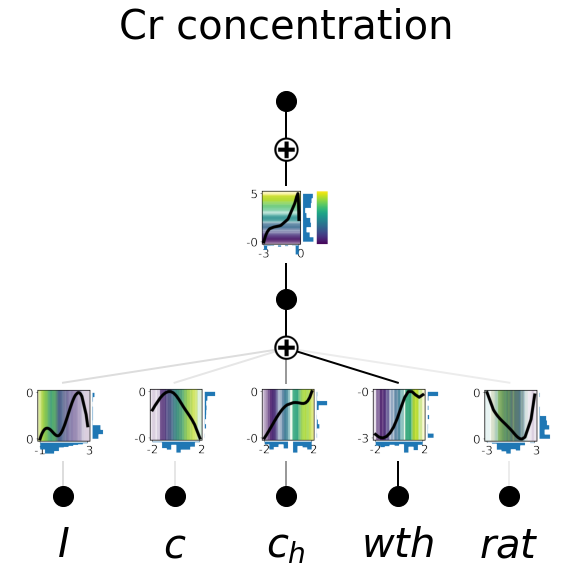

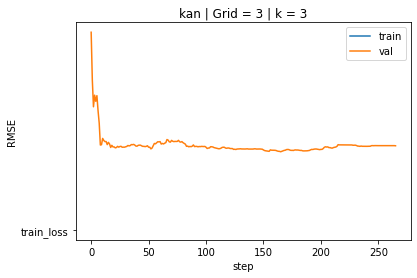

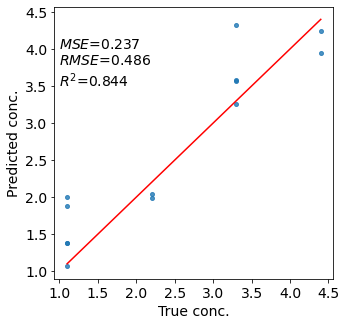

(0.23660308076414838, 0.8441216254126732)

In [4]:
grid, k = 3, 3

model = KANRegressor(hidden_layer_sizes=[1], seed=42, grid=grid, k=k, 
                       solver="lbfgs", 
                       n_iter_no_change = 100, 
                       max_iter=1000, 
                       lamb=1e-2,
                       lamb_l1=1,
                       lamb_entropy=2)

model.fit(x_train, y_train)
result = model.kan.results

model.predict(x_train) # feed-forward for plotting

prnt_kwrgs = {'in_vars': ['$I$', '$c$', '$c_h$', '$wth$', '$rat$'], 
              'out_vars': [PREDICT_IONS + ' concentration'], 
              'tick': True,
              'title': None,
              'sample': True,
              'scale': 1,
              'scale_scatter': 0.7}

#model2.kan.plot(**prnt_kwrgs, reper_in_out=np.nan, reper_index=np.nan, hist_plot=False)
#model2.kan.plot(**prnt_kwrgs, reper_in_out=np.nan, reper_index=np.nan, hist_plot=True)

#model2.kan.plot(**prnt_kwrgs, reper_in_out='in', reper_index=0, hist_plot=False)
#model2.kan.plot(**prnt_kwrgs, reper_in_out='in', reper_index=0, hist_plot=True)

#model2.kan.plot(**prnt_kwrgs, reper_in_out='out', reper_index=0, hist_plot=False)
model.kan.plot(**prnt_kwrgs, reper_in_out='out', reper_index=0, hist_plot=True)
plt.show()

plt.plot(
         ['train_loss'])
plt.plot(result['test_loss'])
#plt.plot(result['reg'])
plt.legend(['train', 'val']) #, 'reg'
plt.title(f'kan | Grid = {grid} | k = {k}')
plt.ylabel('RMSE')
plt.xlabel('step')
plt.show()

scatter_prediction_skl(model, x_test, y_test, f"Test dataset")

# $\lambda$-KAN

checkpoint directory created: ./model
saving model version 0.0


description:   0%|                                                         | 0/1000 [00:00<?, ?it/s]

| trn_loss: 2.78e-01 | tst_loss: 3.44e-01 | e_stop: 100/100 | reg: 9.00e+00 | :  10%| | 102/1000 [00


Early stopping criteria raised
saving model version 0.1


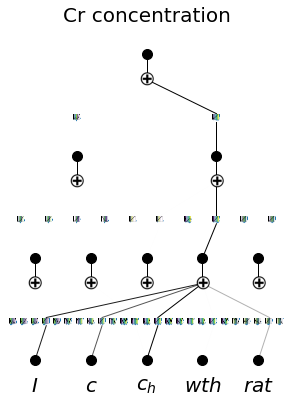

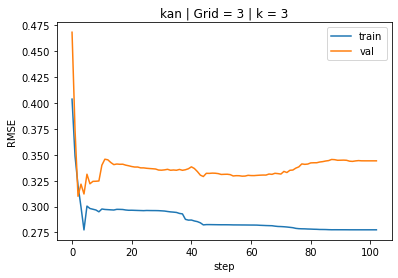

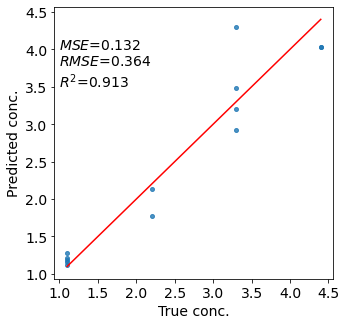

module of Input importance:


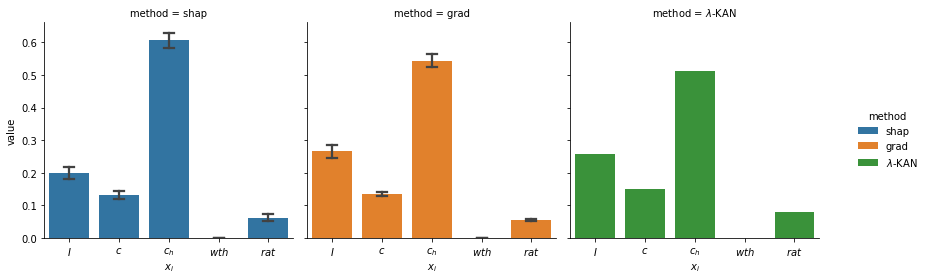

Input importance:


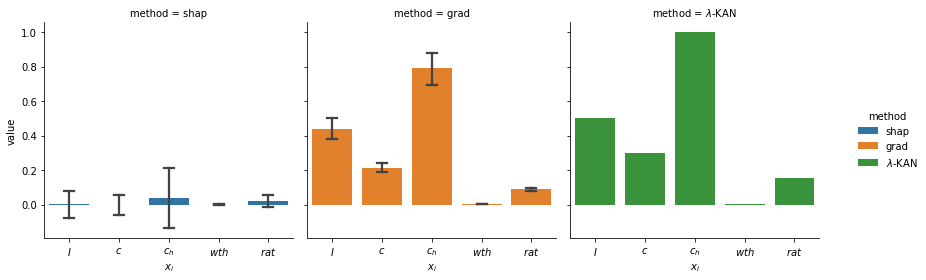

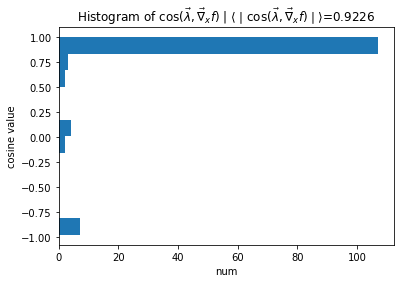

In [5]:
grid, k = 3, 3

model = lmdKANRegressor(hidden_layer_sizes=[5,2,], seed=42, grid=grid, k=k, 
                        solver="lbfgs",
                        n_iter_no_change = 100, 
                        max_iter=1000, 
                        lamb=1e-2,
                        lamb_l1=1,
                        lamb_entropy=2)

model.fit(x_train, y_train)
model.predict(x_train)

result = model.kan.results

prnt_kwrgs = {'in_vars': ['$I$', '$c$', '$c_h$', '$wth$', '$rat$'], 
            'out_vars': [PREDICT_IONS + ' concentration'], 
            'title': None,
            'sample': True,
            'scale': 0.5,
            'scale_scatter': 0.5}

model.kan.plot(**prnt_kwrgs, reper_in_out='out', reper_index=0, hist_plot=True)

plt.plot(result['train_loss'])
plt.plot(result['test_loss'])
#plt.plot(result['reg'])
plt.legend(['train', 'val']) #, 'reg'
plt.title(f'kan | Grid = {grid} | k = {k}')
plt.ylabel('RMSE')
plt.xlabel('step')
plt.show()

scatter_prediction_skl(model, x_test, y_test, f"Test dataset")

importance_analyse_lmdKAN(model.kan, dict(test_input=torch.tensor(scaler.transform(x), dtype=torch.float)))
plt.show()